c:\Users\domin\Code_Projects\MSc_Geomatics\Master_thesis\SpatialFoundationModel\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Current working directory: c:\Users\domin\Code_Projects\MSc_Geomatics\Master_thesis\SpatialFoundationModel\notebooks
{'mean': tensor([  37.0168, -121.9833,    0.5838,    0.5836,    0.5013,    0.5837,
           0.5001,    0.4993]), 'std': tensor([0.0555, 0.0556, 0.2776, 0.2778, 0.2882, 0.1571, 0.2290, 0.2885]), 'scale': tensor([0.7071, 0.7071, 0.5774, 0.5774, 0.5774, 0.5774, 0.5774, 0.5774])}
{'coords': torch.Size([256, 2]), 'mod1': torch.Size([256, 3]), 'mod2': torch.Size([256, 3])}


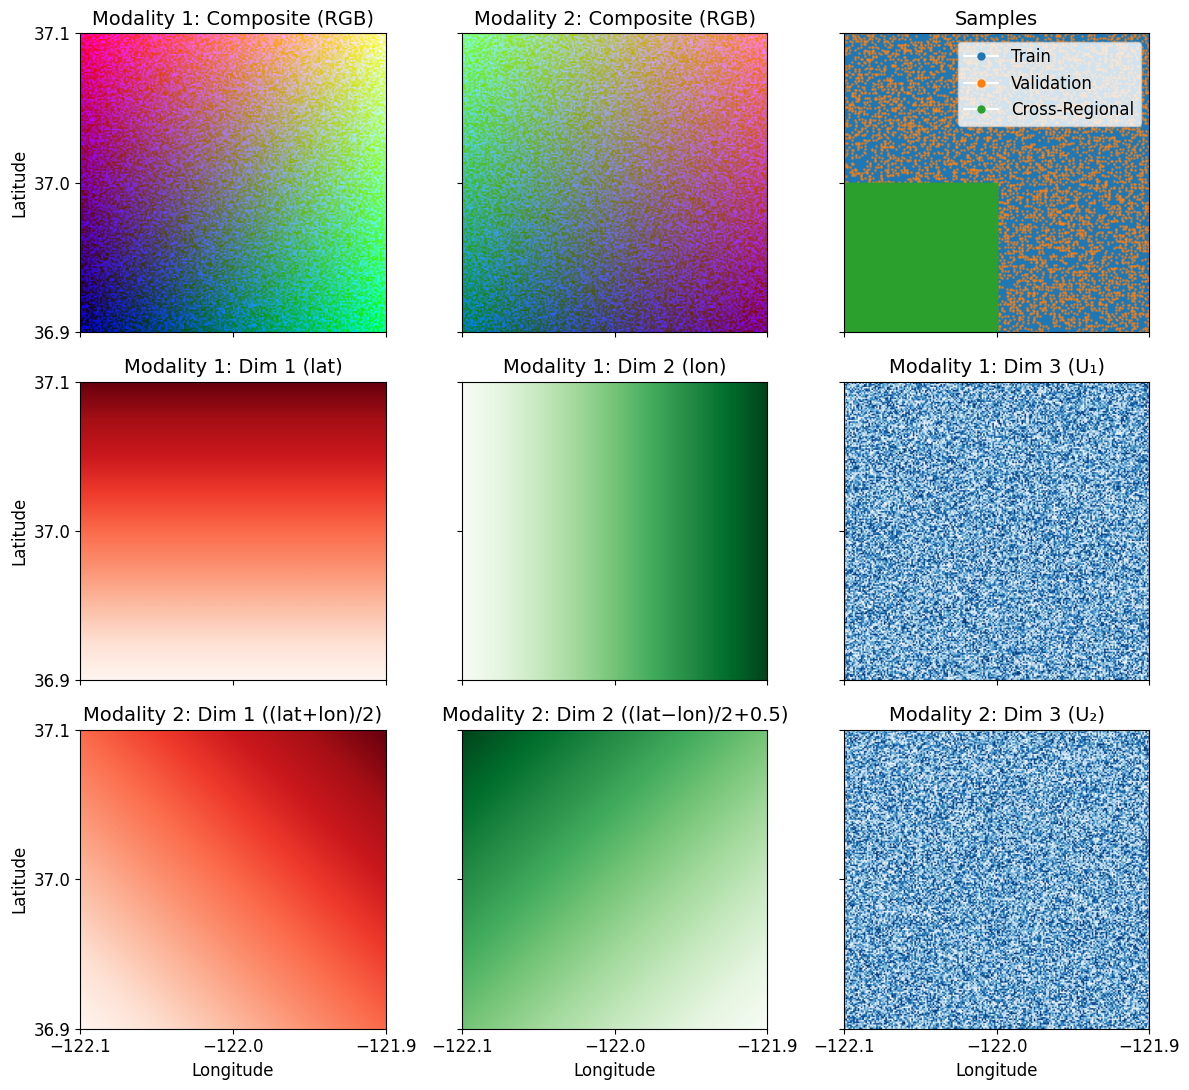

In [1]:
#!/usr/bin/env python3
"""
Description: Jupyter notebook for synthetic data experiment for partial information decomposition.
"""
from collections import defaultdict
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from srl.data.syntheticPID import SyntheticGeoDataModule, plot_modalities
from srl.multi_modal_encoder.multi_modal_transformer import MultiModalTransformer
from srl.encoders.coordinate_encoder import CoordinateEncoder
from srl.encoders.synthetic_RGB_encoder.rgb_encoder import RGBEncoder
from srl.baselines.GAIR.model.GAIR import GAIR
from srl.baselines.geoclip.model.GeoCLIP import GeoCLIP
import os
print("Current working directory:", os.getcwd(), flush=True)
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
os.chdir(parent_dir)

# Get synthetic data
dm = SyntheticGeoDataModule(batch_size=256, num_workers=0)
dm.setup()
batch = next(iter(dm.train_dataloader()))
print({k: v.shape for k, v in batch.items()})
plot_modalities(
    dm.raw_np_data["lat2d"],
    dm.raw_np_data["lon2d"],
    dm.raw_np_data["mod1"].reshape(200, 200, 3),
    dm.raw_np_data["mod2"].reshape(200, 200, 3),
    dm.raw_np_data["train_idx"],
    dm.raw_np_data["val_idx"],
    dm.raw_np_data["crg_idx"],
)

In [2]:
# Configuration
plt.rcParams["figure.dpi"] = 120
SEED     = 42
N_SPLITS = 5
alphas = np.logspace(-4, 4, 100)       # RidgeCV grid [10−4, 104]
PALETTE = ['#1f77b4', '#aec7e8', '#ff7f0e', '#2ca02c']
METHOD_ORDER = ["UrbanFusion (CL + Rec.)",
                "UrbanFusion (CL)",
                "GAIR",
                "GeoCLIP"
            ]
# Paths to representations
REPRESENTATION_PATHS = {
    "UrbanFusion (CL + Rec.)": {
        0: r"logs\UrbanFusionV1SyntheticPID_4\runs\2025-07-19_12-08-32\plots\representations_test_epoch_250_masked_modality_none_dl_0.pt",
        1: r"logs\UrbanFusionV1SyntheticPID_4\runs\2025-07-19_12-08-32\plots\representations_test_epoch_250_masked_modality_none_dl_1.pt",
    },
    "UrbanFusion (CL)"     : {
        0: r"logs\UrbanFusionV1SyntheticPID_5\runs\2025-07-19_18-35-56\plots\representations_test_epoch_250_masked_modality_none_dl_0.pt",
        1: r"logs\UrbanFusionV1SyntheticPID_5\runs\2025-07-19_18-35-56\plots\representations_test_epoch_250_masked_modality_none_dl_1.pt",
    },
    "GAIR"                 : {
        0: r"logs\GAIRSyntheticPID_1\runs\2025-07-19_12-21-35\plots\representations_test_epoch_250_modality_6_dl_0.pt",
        1: r"logs\GAIRSyntheticPID_1\runs\2025-07-19_12-21-35\plots\representations_test_epoch_250_modality_6_dl_1.pt",
    },
    "GeoCLIP"              : {
        0: r"logs\GeoCLIPSyntheticPID_1\runs\2025-07-19_12-31-55\plots\representations_test_epoch_250_modality_2_dl_0.pt",
        1: r"logs\GeoCLIPSyntheticPID_1\runs\2025-07-19_12-31-55\plots\representations_test_epoch_250_modality_2_dl_1.pt",
    },
}


def ridge_cv_r2(X: np.ndarray, tasks: dict) -> dict:
    """
    Returns a dict {task_name: [r2_fold1, r2_fold2, …]} using 5‑fold CV.

    Parameters
    ----------
    X : np.ndarray
        The input features.
    tasks : dict
        A dictionary mapping task names to their target values.

    Returns
    -------
    dict
        A dictionary mapping task names to their R² scores for each fold.
    """
    outer = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    task_to_scores = {name: [] for name in tasks}
    for tr_idx, te_idx in outer.split(X):
        X_tr, X_te = X[tr_idx], X[te_idx]
        for name, y in tasks.items():
            y_tr, y_te = y[tr_idx], y[te_idx]
            cv_model = RidgeCV(alphas=alphas, cv=None)
            cv_model.fit(X_tr, y_tr)
            final = Ridge(alpha=cv_model.alpha_)
            final.fit(X_tr, y_tr)
            y_pred = final.predict(X_te)
            task_to_scores[name].append(r2_score(y_te, y_pred))

    return task_to_scores


# Run evaluation for every (method, dataloader)
fold_stats = defaultdict(lambda: defaultdict(dict))  # nested dict for results

for method, dl_dict in REPRESENTATION_PATHS.items():
    for dl_idx, rep_path in dl_dict.items():

        # Load representation tensor
        reps = torch.load(rep_path).detach().cpu().numpy()  # (n, dim)

        val_loader = dm.val_dataloader()  # (or dm.val_dataloader()[0] if you returned a list)

        # Accumulate every batch
        stash = defaultdict(list)

        for batch in val_loader[dl_idx]:
            for k, v in batch.items():
                if torch.is_tensor(v):
                    v = v.detach().cpu()
                stash[k].append(v)

        # Stitch each key into one tensor / array
        full_val = {}
        for k, items in stash.items():
            first = items[0]
            if torch.is_tensor(first):
                full_val[k] = torch.cat(items, dim=0)
            else:
                full_val[k] = np.concatenate(items, axis=0)

        print({k: v.shape for k, v in full_val.items()})


        # Assemble design matrix and four targets 
        X = reps

        # Assemble the four raw target arrays
        coords = full_val['coords'].cpu().numpy()  # (n, 2)
        mod1_d2 = full_val['mod1'][:, 2].cpu().numpy()  # (n,)
        mod2_d2 = full_val['mod2'][:, 2].cpu().numpy()  # (n,)
        U1 = full_val['mod1'][:, 2].cpu().numpy().astype(float)
        U2 = full_val['mod2'][:, 2].cpu().numpy().astype(float)
        synergy = (U1 + U2)

        task_dict = {
            "coords": coords,
            "mod1_d2": mod1_d2,
            "mod2_d2": mod2_d2,
            "synergy": synergy,
        }

        # Run Ridge‑CV evaluation
        task2r2 = ridge_cv_r2(reps, task_dict)
        fold_stats[method][dl_idx] = task2r2


# Aggregate into DataFrame
# (Redundancy, Uniqueness, Synergy) × (method) × (dataloader)
aggreg = defaultdict(list)
for method, dls in fold_stats.items():
    for dl_idx, tasks in dls.items():

        # Redundancy = coords
        r2_red = np.mean(tasks['coords'])
        sd_red = np.std(tasks['coords'])

        # Uniqueness = mean over mod1_d2 & mod2_d2 folds stacked
        uniq_folds = tasks['mod1_d2'] + tasks['mod2_d2']
        r2_unq = np.mean(uniq_folds)
        sd_unq = np.std(uniq_folds)

        # Synergy
        r2_syn = np.mean(tasks['synergy'])
        sd_syn = np.std(tasks['synergy'])

        for atask, mean, std in [("Redundancy", r2_red, sd_red),
                                 ("Uniqueness", r2_unq, sd_unq),
                                 ("Synergy",    r2_syn, sd_syn)]:
            aggreg['dataloader'].append(f"DL {dl_idx}")
            aggreg['method'].append(method)
            aggreg['analysis_task'].append(atask)
            aggreg['r2_mean'].append(mean)
            aggreg['r2_std'].append(std)

df = pd.DataFrame(aggreg)
print(df.head())


{'coords': torch.Size([6000, 2]), 'mod1': torch.Size([6000, 3]), 'mod2': torch.Size([6000, 3])}
{'coords': torch.Size([10000, 2]), 'mod1': torch.Size([10000, 3]), 'mod2': torch.Size([10000, 3])}
{'coords': torch.Size([6000, 2]), 'mod1': torch.Size([6000, 3]), 'mod2': torch.Size([6000, 3])}
{'coords': torch.Size([10000, 2]), 'mod1': torch.Size([10000, 3]), 'mod2': torch.Size([10000, 3])}
{'coords': torch.Size([6000, 2]), 'mod1': torch.Size([6000, 3]), 'mod2': torch.Size([6000, 3])}


c:\Users\domin\Code_Projects\MSc_Geomatics\Master_thesis\SpatialFoundationModel\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.91983e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\domin\Code_Projects\MSc_Geomatics\Master_thesis\SpatialFoundationModel\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.91983e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\domin\Code_Projects\MSc_Geomatics\Master_thesis\SpatialFoundationModel\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.93986e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\domin\Code_Projects\MSc_Geomatics\Master_thesis\SpatialFoundationModel\venv\Lib\site-packages\sklearn\linear_model\_ri

{'coords': torch.Size([10000, 2]), 'mod1': torch.Size([10000, 3]), 'mod2': torch.Size([10000, 3])}
{'coords': torch.Size([6000, 2]), 'mod1': torch.Size([6000, 3]), 'mod2': torch.Size([6000, 3])}
{'coords': torch.Size([10000, 2]), 'mod1': torch.Size([10000, 3]), 'mod2': torch.Size([10000, 3])}
  dataloader                   method analysis_task   r2_mean    r2_std
0       DL 0  UrbanFusion (CL + Rec.)    Redundancy  0.996875  0.000148
1       DL 0  UrbanFusion (CL + Rec.)    Uniqueness  0.993005  0.001722
2       DL 0  UrbanFusion (CL + Rec.)       Synergy  0.993802  0.000394
3       DL 1  UrbanFusion (CL + Rec.)    Redundancy  0.992537  0.000199
4       DL 1  UrbanFusion (CL + Rec.)    Uniqueness  0.994750  0.002147


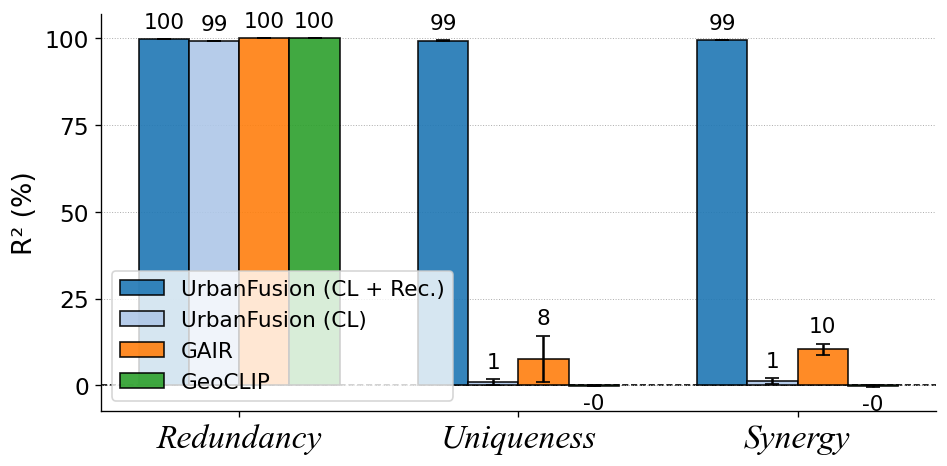

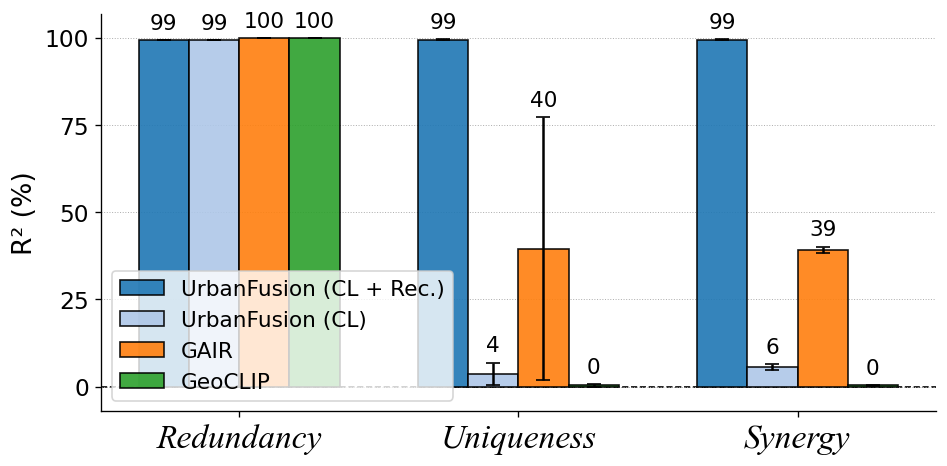

In [3]:
# Plotting function (bar plot with error bars and annotations)
bar_w    = 0.18
x_groups = ["Redundancy", "Uniqueness", "Synergy"]
x_pos    = np.arange(len(x_groups))

LABEL_FONT = 16
TICK_FONT = 14
ANNOT_FONT = 13
LEGEND_FONT = 13
LEGEND_TITLE_FONT = 13

def plot_dl(dl_label: str, sub_df: pd.DataFrame) -> None:
    """
    Plots a bar chart for a specific dataloader.

    Parameters
    ----------
    dl_label : str
        The label for the dataloader.
    sub_df : pd.DataFrame
        The subset of the DataFrame containing results for the specific dataloader.
    """
    fig, ax = plt.subplots(figsize=(8, 4))
    pivot_mean = (
        sub_df.assign(r2_mean=lambda d: d.r2_mean * 100)         # 0.23 → 23 %
              .pivot(index="analysis_task", columns="method", values="r2_mean")
    )
    pivot_sd   = (
        sub_df.assign(r2_std =lambda d: d.r2_std  * 100)         # 0.04 → 4 %
              .pivot(index="analysis_task", columns="method", values="r2_std")
    )
    min_val = (pivot_mean - pivot_sd).min().min()
    max_val = (pivot_mean + pivot_sd).max().max()
    for i, method in enumerate(METHOD_ORDER):
        vals = pivot_mean[method].reindex(x_groups).values
        errs = pivot_sd[method].reindex(x_groups).values
        bars = ax.bar(
            x_pos + i*bar_w - 1.5*bar_w,
            vals,
            yerr=errs,
            width=bar_w,
            capsize=4,
            edgecolor="black",
            color=PALETTE[i],
            label=method,
            alpha=0.90,
            zorder=2,
        )
        padding = 0.02 * (max_val - min_val or 1)
        for bar, v, err in zip(bars, vals, errs):
            if v >= 0:
                y_label = v + err + padding
                va      = "bottom"
            else:
                y_label = v - err - padding
                va      = "top"
            ax.text(
                bar.get_x() + bar.get_width()/2,
                y_label,
                f"{v:.0f}",
                ha="center", va=va, fontsize=ANNOT_FONT
            )
    pad = 0.07 * (max_val - min_val or 1)
    ax.set_ylim(min(min_val, 0) - pad, max_val + pad)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.axhline(0, lw=1, ls="--", color="k", zorder=0)
    ax.set_xticks(x_pos, x_groups, fontsize=TICK_FONT)
    ax.tick_params(axis="y", labelsize=TICK_FONT)
    ax.set_ylabel("R² (%)", fontsize=LABEL_FONT)
    ax.grid(axis="y", ls=":", lw=.6, zorder=1)
    ax.legend(
        loc="lower left",
        fontsize=LEGEND_FONT,
        title_fontsize=LEGEND_TITLE_FONT
    )
    for spine in ("right", "top"):
        ax.spines[spine].set_visible(False)
    for label in ax.get_xticklabels():
        label.set_fontname("Times New Roman")
        label.set_fontstyle("italic")
        label.set_fontsize(20)
    plt.tight_layout()
    plt.show()

for dl in sorted(df["dataloader"].unique()):
    plot_dl(dl, df[df.dataloader == dl])


                   Model  Modality 1  Modality 2
0  UrbanFusion (CL+Rec.)   32.706076   39.227393
1       UrbanFusion (CL)    0.971804    9.805837
2                   GAIR    3.596617   22.980532
3                GeoCLIP    0.269310         NaN


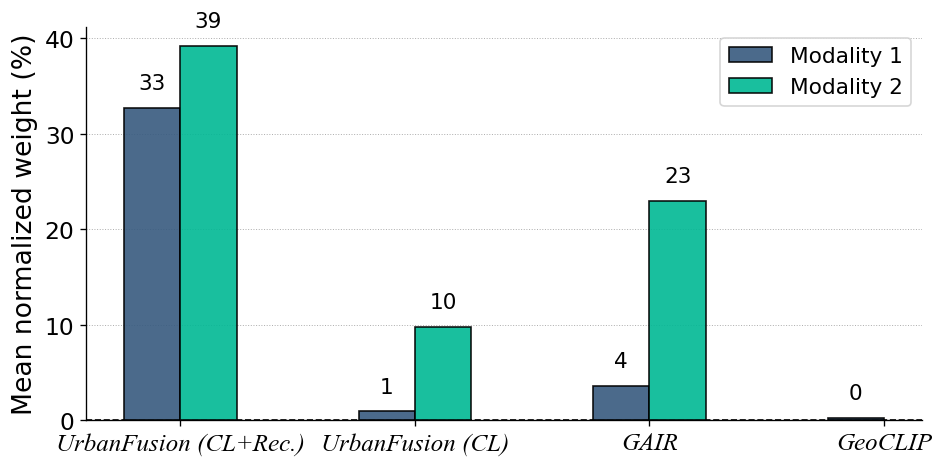

In [4]:
# Plot weights statistics
def load_state_dict(checkpoint_path: str, strict: bool = True) -> dict:
    """
    Loads the state dict from a checkpoint file.

    Parameters
    ----------
    checkpoint_path : str
        The path to the checkpoint file.
    strict : bool
        Whether to enforce strict loading (default: True).

    Returns
    -------
    dict
        The loaded state dict.
    """
    ckpt = torch.load(checkpoint_path, weights_only=False)
    state_dict = ckpt.get("state_dict", ckpt)
    new_state_dict = {k[len("model."): ] if k.startswith("model.") else k: v
                      for k, v in state_dict.items()
                      if not (k.startswith("model.loss.") or k.startswith("loss."))}
    return new_state_dict


def get_mean_relative_contribution(weight: torch.Tensor) -> float:
    """
    Computes the mean relative contribution of a specific modality from the weight tensor.

    Parameters
    ----------
    weight : torch.Tensor
        The weight tensor from a modality's neural network.

    Returns
    -------
    float
        The mean relative contribution of the modality (in percent).
    """
    W_abs = weight.abs()
    W_norm = W_abs / W_abs.sum(dim=1, keepdim=True)
    return W_norm[:, 2].mean().item() * 100  # in percent

results = []

# UrbanFusion (CL+Rec.)
urbanfusion = MultiModalTransformer(
    encoders=[
        CoordinateEncoder(
            positional_encoding_name="direct_no_rad",
            neural_network_name="rff",
            embed_dim=9,
            seq_len=1,
            dim_hidden=9,
            num_layers=2,
            dropout=0.0,
            legendre_polys=10,
            harmonics_calculation="analytic",
            min_radius=None,
            max_radius=None,
            frequency_num=None,
            return_encoding=False,
            precomputed_features=True,
            cartesian_3d_branch=False,
            cartesian_3d_input_dropout=1.0,
            synthetic=True
        ),  # same as before
        RGBEncoder(dim_hidden=4, dim_out=9, as_tokens=True),
        RGBEncoder(dim_hidden=4, dim_out=9, as_tokens=True),
    ],
    transformer_type="single", embed_dim=9, head_hidden_dim=9,
    hourglass_dim=9, head_contrastive_dim=9, num_heads=1,
    only_cls=True, avg_pool=True, head="hourglass_tiny",
    reconstruction_head_dim=8, depth=1
)
uf_ckpt_clrec = r"logs\\UrbanFusionV1SyntheticPID_4\\runs\\2025-07-19_12-08-32\\checkpoints\\last.ckpt"
urbanfusion.load_state_dict(load_state_dict(uf_ckpt_clrec), strict=True)
mod1 = get_mean_relative_contribution(urbanfusion.encoders[1].net[0].weight)
mod2 = get_mean_relative_contribution(urbanfusion.encoders[2].net[0].weight)
results.append({'Model': "UrbanFusion (CL+Rec.)", 'Modality 1': mod1, 'Modality 2': mod2})

# UrbanFusion (CL)
urbanfusion2 = MultiModalTransformer(
    encoders=[
                CoordinateEncoder(
            positional_encoding_name="direct_no_rad",
            neural_network_name="rff",
            embed_dim=9,
            seq_len=1,
            dim_hidden=9,
            num_layers=2,
            dropout=0.0,
            legendre_polys=10,
            harmonics_calculation="analytic",
            min_radius=None,
            max_radius=None,
            frequency_num=None,
            return_encoding=False,
            precomputed_features=True,
            cartesian_3d_branch=False,
            cartesian_3d_input_dropout=1.0,
            synthetic=True
        ),  # same as before
        RGBEncoder(dim_hidden=4, dim_out=9, as_tokens=True),
        RGBEncoder(dim_hidden=4, dim_out=9, as_tokens=True),
    ],
    transformer_type="single", embed_dim=9, head_hidden_dim=9,
    hourglass_dim=9, head_contrastive_dim=9, num_heads=1,
    only_cls=True, avg_pool=True, head="hourglass_tiny",
    reconstruction_head_dim=8, depth=1
)
uf_ckpt_cl = r"logs\\UrbanFusionV1SyntheticPID_5\\runs\\2025-07-19_18-35-56\\checkpoints\\last.ckpt"
urbanfusion2.load_state_dict(load_state_dict(uf_ckpt_cl), strict=True)
mod1 = get_mean_relative_contribution(urbanfusion2.encoders[1].net[0].weight)
mod2 = get_mean_relative_contribution(urbanfusion2.encoders[2].net[0].weight)
results.append({'Model': "UrbanFusion (CL)", 'Modality 1': mod1, 'Modality 2': mod2})

# GAIR
gair = GAIR(queue_size=0, precomputed_features=False, synthetic_experiment=True)
gair_ckpt = r"logs\\GAIRSyntheticPID_1\\runs\\2025-07-19_12-21-35\\checkpoints\\last.ckpt"
gair.load_state_dict(load_state_dict(gair_ckpt), strict=True)
mod1 = get_mean_relative_contribution(gair.svi_encoder.net[0].weight)
mod2 = get_mean_relative_contribution(gair.rs_encoder.net[0].weight)
results.append({'Model': "GAIR", 'Modality 1': mod1, 'Modality 2': mod2})

# GeoCLIP 
geoclip = GeoCLIP(queue_size=0, precomputed_features=False, synthetic_experiment=True, from_pretrained=False)
geoclip_ckpt = r"logs\\GeoCLIPSyntheticPID_1\\runs\\2025-07-19_12-31-55\\checkpoints\\last.ckpt"
geoclip.load_state_dict(load_state_dict(geoclip_ckpt), strict=True)
mod1 = get_mean_relative_contribution(geoclip.image_encoder.net[0].weight)
results.append({'Model': "GeoCLIP", 'Modality 1': mod1, 'Modality 2': None})

# Save to DataFrame
df = pd.DataFrame(results)
print(df)
#df.to_csv("modality_relative_contributions.csv", index=False)


# Color palette and labels
PALETTE = ["#375a7f", "#00b894"]
MODALITY_LABELS = ["Modality 1", "Modality 2"]
# Color palette and labels
PALETTE = ["#375a7f", "#00b894"]
MODALITY_LABELS = ["Modality 1", "Modality 2"]

def plot_modality_contributions(df: pd.DataFrame) -> None:
    """
    Plots the mean relative contributions of different modalities.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the model names and their corresponding modality contributions.
    """
    bar_w = 0.24
    x_models = df["Model"].tolist()
    x_pos = np.arange(len(x_models))
    fig, ax = plt.subplots(figsize=(8, 4))
    mod1 = df["Modality 1"].tolist()
    mod2_raw = df["Modality 2"].tolist()
    mod2 = [m2 if m2 is not None else 0 for m2 in mod2_raw]
    bars1 = ax.bar(
        x_pos - bar_w/2, mod1, width=bar_w, label=MODALITY_LABELS[0],
        color=PALETTE[0], edgecolor="black", alpha=0.90, zorder=2
    )
    bars2 = ax.bar(
        x_pos + bar_w/2, mod2, width=bar_w, label=MODALITY_LABELS[1],
        color=PALETTE[1], edgecolor="black", alpha=0.90, zorder=2
    )
    for bars, vals in zip([bars1, bars2], [mod1, mod2_raw]):
        for bar, v in zip(bars, vals):
            if v is not None:
                y = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    y + 1.5,
                    f"{y:.0f}", ha="center", va="bottom", fontsize=ANNOT_FONT
                )
    ax.axhline(0, lw=1, ls="--", color="k", zorder=0)
    ax.set_xticks(x_pos, x_models, fontsize=TICK_FONT)
    ax.tick_params(axis="y", labelsize=TICK_FONT)
    ax.set_ylabel("Mean normalized weight (%)", fontsize=LABEL_FONT)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    handles, labels = ax.get_legend_handles_labels()
    if all(x is None for x in df["Modality 2"]):
        handles, labels = handles[:1], labels[:1]
    ax.grid(axis="y", ls=":", lw=.6, zorder=1)
    ax.legend(
        handles, labels,
        fontsize=LEGEND_FONT, title_fontsize=LEGEND_TITLE_FONT,
        loc='upper right'
    )
    for spine in ("right", "top"):
        ax.spines[spine].set_visible(False)
    for label in ax.get_xticklabels():
        label.set_fontname("Times New Roman")
        label.set_fontstyle("italic")
        label.set_fontsize(15)

    plt.tight_layout()
    plt.show()

plot_modality_contributions(df)
